In [1]:
import pandas as pd



In [2]:
import os
import pandas as pd

# List all CSV files in the pbp folder
pbp_folder = 'pbp'
csv_files = [f for f in os.listdir(pbp_folder) if f.endswith('.csv')]

# Sort files by year (assuming filename format pbpYYYY.csv)
csv_files.sort()

# Read and concatenate all CSV files
dfs = []
for file in csv_files:
    file_path = os.path.join(pbp_folder, file)
    df = pd.read_csv(file_path)
    dfs.append(df)

# Concatenate all dataframes
pbp_data = pd.concat(dfs, ignore_index=True)

# Display the shape of the combined dataframe
print(f"Combined PBP data shape: {pbp_data.shape}")
pbp_data.head()


Combined PBP data shape: (16215625, 16)


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season
0,29600001,1,PT12M00.00S,0.0,0.0,NaN,0,NaN,period,start,NaN,0,0,0,Start of 1st Period (11:15 PM EST),1997
1,29600001,1,PT12M00.00S,0.0,0.0,BOS,442,P. Ellison,Jump Ball,NaN,NaN,0,0,0,Jump Ball Ellison vs. Longley: Tip to Harper,1997
2,29600001,1,PT11M39.00S,0.0,2.0,CHI,23,D. Rodman,Made Shot,Layup Shot,Made,0,0,0,Rodman Layup (2 PTS) (Longley 1 AST),1997
3,29600001,1,PT11M39.00S,0.0,0.0,BOS,442,P. Ellison,Foul,Shooting,NaN,0,0,0,Ellison S.FOUL (P1.T1),1997
4,29600001,1,PT11M39.00S,0.0,3.0,CHI,23,D. Rodman,Free Throw,Free Throw 1 of 1,NaN,0,0,0,Rodman Free Throw 1 of 1 (3 PTS),1997


In [3]:
pbp_data = pbp_data[pbp_data["type"].isin(["Made Shot", "Missed Shot"])]
pbp_data = pbp_data[pbp_data["player"] == "S. Curry"]


In [4]:
pbp_data.head()


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season
7721429,20900015,1,PT11M25.00S,0.0,0.0,GSW,201939,S. Curry,Missed Shot,Jump Shot,Missed,99,249,27,MISS Curry 27' 3PT Jump Shot,2010
7721444,20900015,1,PT09M31.00S,4.0,2.0,GSW,201939,S. Curry,Made Shot,Step Back Jump shot,Made,-122,145,19,Curry 19' Step Back Jump Shot (2 PTS),2010
7721480,20900015,1,PT06M02.00S,0.0,0.0,GSW,201939,S. Curry,Missed Shot,Jump Shot,Missed,-60,129,14,MISS Curry 14' Jump Shot,2010
7721565,20900015,2,PT09M49.00S,0.0,0.0,GSW,201939,S. Curry,Missed Shot,Jump Shot,Missed,-172,82,19,MISS Curry 19' Jump Shot,2010
7721659,20900015,2,PT02M19.00S,0.0,0.0,GSW,201939,S. Curry,Missed Shot,Jump Shot,Missed,-68,148,16,MISS Curry 16' Jump Shot,2010


In [5]:
pbp_data = pbp_data[pbp_data["season"] == 2016]

pbp_data.drop(columns=["desc", "season"], inplace=True)
pbp_data.head()


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist
11343626,21500003,1,PT10M56.00S,5.0,2.0,GSW,201939,S. Curry,Made Shot,Cutting Finger Roll Layup Shot,Made,12,31,3
11343629,21500003,1,PT10M29.00S,NaN,NaN,GSW,201939,S. Curry,Missed Shot,Jump Shot,Missed,-176,195,26
11343634,21500003,1,PT09M34.00S,NaN,NaN,GSW,201939,S. Curry,Missed Shot,Layup Shot,Missed,20,9,2
11343639,21500003,1,PT09M13.00S,10.0,7.0,GSW,201939,S. Curry,Made Shot,Jump Shot,Made,-197,193,28
11343658,21500003,1,PT07M11.00S,14.0,11.0,GSW,201939,S. Curry,Made Shot,Running Layup Shot,Made,-4,8,1


In [6]:
pbp_data.to_csv("curry_shots.csv", index=False)


In [34]:
curry_shots = pd.read_csv("curry_shots.csv")
curry_shots["clock"] = pd.to_timedelta(curry_shots["clock"])
quarter_length = pd.Timedelta(minutes=12)
curry_shots["clock"] = quarter_length - curry_shots["clock"]
curry_shots = curry_shots[curry_shots["gameid"] == 21500003]
curry_shots = curry_shots.sort_values(["period", "clock"], ascending=True)
curry_shots.head()


curry_shots["isMade"] = curry_shots["type"] == "Made Shot"
curry_shots["cumulativeMade"] = curry_shots["isMade"].cumsum()
curry_shots["cumulativeMissed"] = (~curry_shots["isMade"]).cumsum()
curry_shots["percentage"] = curry_shots["cumulativeMade"] / (curry_shots["cumulativeMade"] + curry_shots["cumulativeMissed"])
curry_shots["elapsed_time"] = (curry_shots["period"] - 1) * pd.Timedelta(minutes=12) + curry_shots["clock"]
curry_shots["consecutive_shots"] = 0
consecutive_makes = 0

for row in curry_shots.itertuples():
    if row.isMade:
        consecutive_makes += 1
    else:
        consecutive_makes = 0
    curry_shots.at[row.Index, "consecutive_shots"] = consecutive_makes


    
shots_after_two = curry_shots[curry_shots["consecutive_shots"].shift(1) == 2]
curry_shots["percentage"] = curry_shots["cumulativeMade"] / (curry_shots["cumulativeMade"] + curry_shots["cumulativeMissed"])
fg_after_two = shots_after_two["isMade"].mean()
overall_fg = curry_shots["isMade"].mean()
shots_after_two.head()



,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,isMade,cumulativeMade,cumulativeMissed,percentage,elapsed_time,consecutive_shots
5,21500003,1,0 days 00:05:15,17.0,13.0,GSW,201939,S. Curry,Made Shot,Jump Shot,Made,-11,259,26,True,4,2,0.666667,0 days 00:05:15,3
12,21500003,1,0 days 00:11:58.600000,NaN,NaN,GSW,201939,S. Curry,Missed Shot,Jump Shot,Missed,-186,345,39,False,9,4,0.692308,0 days 00:11:58.600000,0
19,21500003,3,0 days 00:04:25,73.0,58.0,GSW,201939,S. Curry,Made Shot,Cutting Finger Roll Layup Shot,Made,-7,13,1,True,13,7,0.650000,0 days 00:28:25,3


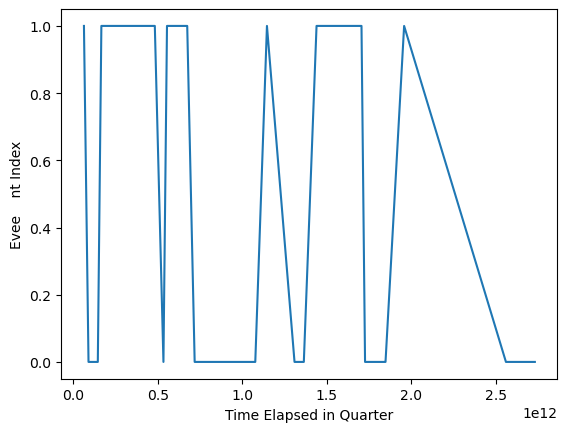

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf


plt.plot(curry_shots["elapsed_time"],curry_shots["percentage"] )
plt.xlabel("Time Elapsed in Quarter")
plt.ylabel("Event Index")
plt.show()

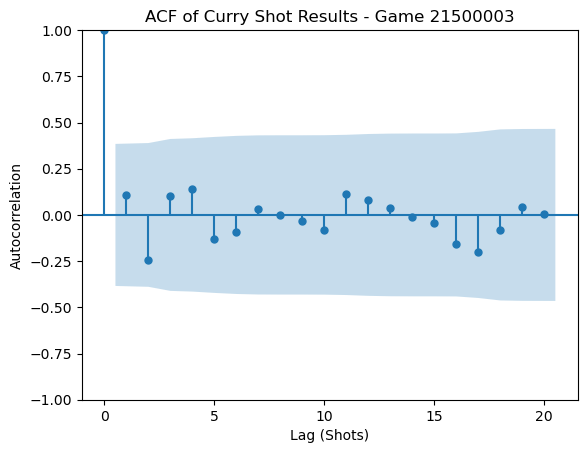

In [9]:
plot_acf(curry_shots["isMade"], lags=20)
plt.xlabel("Lag (Shots)")
plt.ylabel("Autocorrelation")
plt.title("ACF of Curry Shot Results - Game 21500003")
plt.show()

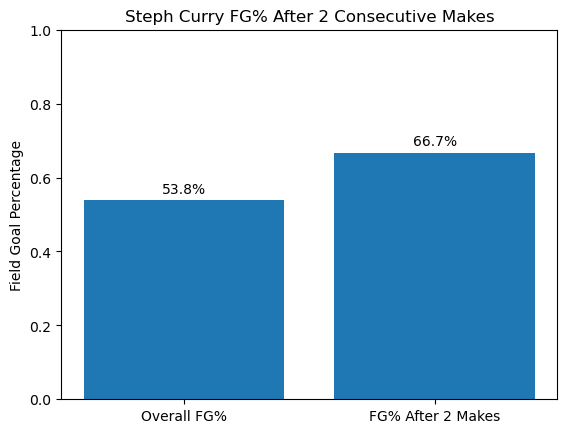

In [35]:
import matplotlib.pyplot as plt

labels = ["Overall FG%", "FG% After 2 Makes"]
values = [overall_fg, fg_after_two]

plt.bar(labels, values)
plt.ylim(0,1)

plt.ylabel("Field Goal Percentage")
plt.title("Steph Curry FG% After 2 Consecutive Makes")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center')

plt.show()

In [ ]:
curry_shots = pd.read_csv("curry_shots.csv")

curry_shots["clock"] = pd.to_timedelta(curry_shots["clock"])
quarter_length = pd.Timedelta(minutes=12)
curry_shots["clock"] = quarter_length - curry_shots["clock"]

curry_shots = curry_shots.sort_values(["gameid", "period", "clock"])
curry_shots["isMade"] = curry_shots["type"] == "Made Shot"
curry_shots["consecutive_shots"] = 0

for game, df_game in curry_shots.groupby("gameid"):

    streak = 0

    for row in df_game.itertuples():
        if row.isMade:
            streak += 1
        else:
            streak = 0

        curry_shots.at[row.Index, "consecutive_shots"] = streak
        

shots_after_two = curry_shots[curry_shots["consecutive_shots"].shift(1) == 4]
shots_after_two = curry_shots[
    (curry_shots["consecutive_shots"].shift(1) == 4) &
    (curry_shots["gameid"] == curry_shots["gameid"].shift(1))
]
fg_after_two = shots_after_two["isMade"].mean()
overall_fg = curry_shots["isMade"].mean()

print("FG% after 4 makes:", fg_after_two)
print("Overall FG%:", overall_fg)
print("Attempts after 4 makes:", len(shots_after_two))

FG% after 2 makes: 0.5333333333333333
Overall FG%: 0.48842592592592593
Attempts after 2 makes: 45


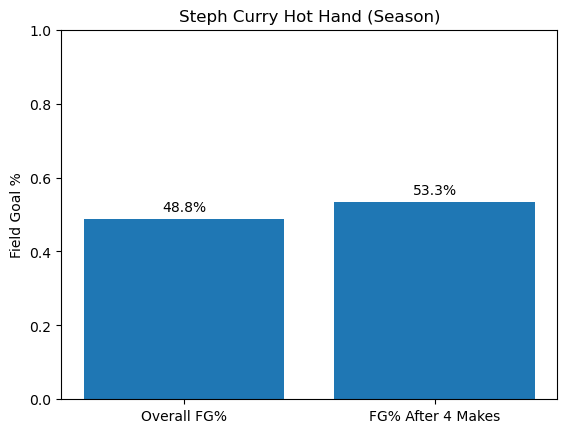

In [43]:
import matplotlib.pyplot as plt

labels = ["Overall FG%", "FG% After 4 Makes"]
values = [overall_fg, fg_after_two]

plt.bar(labels, values)
plt.ylim(0,1)
plt.ylabel("Field Goal %")
plt.title("Steph Curry Hot Hand (Season)")

for i,v in enumerate(values):
    plt.text(i, v+0.02, f"{v*100:.1f}%", ha="center")

plt.show()